# Local install verification (Windows, macOS Apple Silicon, Linux)

Goal: confirm `opencv`, `scikit-learn`, `ultralytics` (YOLO), and `PyTorch` with the best available accelerator (CUDA, MPS, or CPU). All data come from **sklearn built-in** datasets only.

Run this notebook with the **project root** as the working directory (so the `utils` package and `models/` folder resolve correctly). In JupyterLab: `File` - `Open from Path` or start Lab from the repo root.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "utils").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print("Project root:", ROOT)

Project root: C:\2026\gpu_build


In [2]:
from utils.env_check import print_library_versions

print_library_versions()

Python: 3.12.11 (main, Jun  4 2025, 17:41:36) [MSC v.1943 64 bit (AMD64)]
Platform: Windows-11-10.0.26200-SP0
---
numpy: 2.4.4
pandas: 3.0.2
pyarrow: 23.0.1
scipy: 1.17.1
scikit-learn: 1.8.0
matplotlib: 3.10.8
seaborn: 0.13.2
plotly: 6.6.0
pillow: 12.2.0
opencv-python: 4.13.0
torch: 2.11.0+cu128
torchvision: 0.26.0+cu128
ultralytics: 8.4.33
streamlit: 1.56.0
joblib: 1.5.3
openpyxl: 3.1.5
xgboost: 3.2.0
lightgbm: 4.6.0
catboost: 1.2.10
optuna: 4.8.0
statsmodels: 0.14.6
umap-learn: 0.5.11
tqdm: 4.67.3
nbformat: 5.10.4
jupyterlab: 4.5.6
ucimlrepo: 0.0.7


Font result: Malgun Gothic


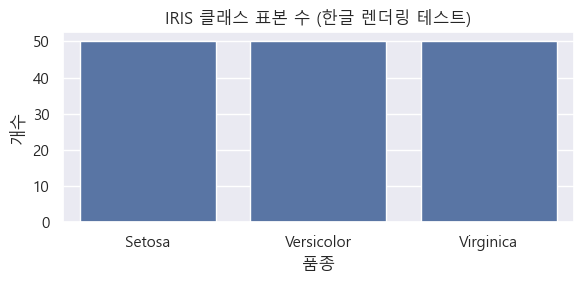

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from utils.env_check import configure_korean_font_matplotlib

font_label = configure_korean_font_matplotlib()
print("Font result:", font_label)

try:
    fig, ax = plt.subplots(figsize=(6, 3))
    names = ["Setosa", "Versicolor", "Virginica"]
    counts = [50, 50, 50]
    sns.barplot(x=names, y=counts, ax=ax)
    ax.set_title("IRIS 클래스 표본 수 (한글 렌더링 테스트)")
    ax.set_xlabel("품종")
    ax.set_ylabel("개수")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Korean plot error:", type(e).__name__, e)

In [4]:
import torch
from utils.env_check import resolve_torch_device

try:
    label, device = resolve_torch_device()
    print("Selected backend:", label, "device:", device)
except Exception as e:
    print("resolve_torch_device error:", type(e).__name__, e)
    label, device = "cpu", torch.device("cpu")

try:
    print("torch.cuda.is_available():", torch.cuda.is_available())
except Exception as e:
    print("CUDA probe:", type(e).__name__, e)

try:
    has_mps = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    print("torch.backends.mps.is_available():", has_mps)
except Exception as e:
    print("MPS probe:", type(e).__name__, e)

Selected backend: cuda device: cuda
torch.cuda.is_available(): True
torch.backends.mps.is_available(): False


In [5]:
from pathlib import Path

import joblib
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

MODELS = ROOT / "models"
MODELS.mkdir(parents=True, exist_ok=True)

try:
    iris = load_iris()
    X_train, X_test, y_train, y_test = train_test_split(
        iris.data,
        iris.target,
        test_size=0.25,
        random_state=42,
        stratify=iris.target,
    )
    clf = RandomForestClassifier(n_estimators=30, random_state=42)
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    print("Holdout accuracy:", accuracy_score(y_test, pred))
    sk_path = MODELS / "sklearn_iris_rf.joblib"
    joblib.dump(clf, sk_path)
    print("Saved sklearn model:", sk_path.resolve())
except Exception as e:
    print("Sklearn train/save error:", type(e).__name__, e)

Holdout accuracy: 0.8947368421052632
Saved sklearn model: C:\2026\gpu_build\models\sklearn_iris_rf.joblib


In [6]:
try:
    import cv2
except ImportError as e:
    print("OpenCV import error:", e)
    cv2 = None

try:
    from sklearn.datasets import load_sample_images

    bundle = load_sample_images()
    rgb = bundle.images[0]
    print("Builtin sample RGB shape:", rgb.shape, rgb.dtype)
    if cv2 is not None:
        bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
        gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
        print("BGR shape:", bgr.shape, "gray shape:", gray.shape)
except Exception as e:
    print("OpenCV / builtin image error:", type(e).__name__, e)

Builtin sample RGB shape: (427, 640, 3) uint8
BGR shape: (427, 640, 3) gray shape: (427, 640)


Download finished; if models/yolov8n.pt is still missing, copy from project root yolov8n.pt manually.
Detection count: 0


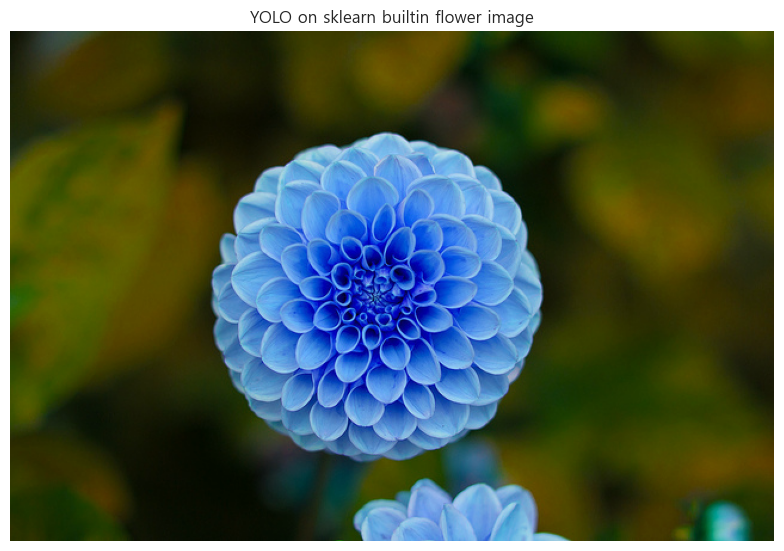

Wrote manifest: C:\2026\gpu_build\models\deploy_manifest.json


In [7]:
import json
import shutil
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import load_sample_images
from utils.env_check import resolve_torch_device

MODELS = ROOT / "models"
MODELS.mkdir(parents=True, exist_ok=True)

try:
    _, device = resolve_torch_device()
except Exception:
    device = torch.device("cpu")

try:
    from ultralytics import YOLO

    target = MODELS / "yolov8n.pt"
    if target.is_file():
        model = YOLO(str(target))
        print("Loaded weights:", target.resolve())
    else:
        model = YOLO("yolov8n.pt")
        local = ROOT / "yolov8n.pt"
        if local.is_file():
            shutil.copy(local, target)
            print("Copied weights to:", target.resolve())
        elif not target.is_file():
            print("Download finished; if models/yolov8n.pt is still missing, copy from project root yolov8n.pt manually.")

    imgs = load_sample_images()
    rgb = imgs.images[1]
    results = model.predict(source=rgb, device=device, verbose=False)
    r0 = results[0]
    nbox = len(r0.boxes) if r0.boxes is not None else 0
    print("Detection count:", nbox)

    plotted = r0.plot()
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    plt.title("YOLO on sklearn builtin flower image")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    manifest = {
        "sklearn_model": str((MODELS / "sklearn_iris_rf.joblib").resolve()),
        "yolo_weights": str((MODELS / "yolov8n.pt").resolve()),
        "torch_device_hint": str(device),
    }
    mp = MODELS / "deploy_manifest.json"
    mp.write_text(json.dumps(manifest, indent=2), encoding="utf-8")
    print("Wrote manifest:", mp.resolve())
except Exception as e:
    print("YOLO / deploy error:", type(e).__name__, e)

## Streamlit smoke test

From the **project root** (same folder as `pyproject.toml`):

```
uv run streamlit run streamlit_verify.py
```

The app loads `models/sklearn_iris_rf.joblib` and `models/yolov8n.pt` and repeats version checks and a short inference pass.